<a href="https://colab.research.google.com/github/lmf55/RNA-e-Deep-Learning---CESAR-School-2025.02/blob/main/Atividade%20Aula%203/Atividade_Aula_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Exam Performance Prediction- Regressão Logística

## Objetivos

Nesta atividade, utilizamos o dataset Student Exam Performance Prediction para treinar um modelo de Regressão Logística com PyTorch.

O objetivo é prever se um estudante será aprovado ou reprovado com base nas variáveis Study Hours e Previous Exam Score.

## Importação das bibliotecas

In [38]:
%matplotlib inline

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score

In [39]:
# Download do dataset Student Exam Performance Prediction do Kaggle
!curl -L -o /content/student-exam-performance.zip https://www.kaggle.com/api/v1/datasets/download/mrsimple07/student-exam-performance-prediction

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 19784  100 19784    0     0  49618      0 --:--:-- --:--:-- --:--:-- 49618


In [40]:
# Descompactando o arquivo
!unzip -o /content/student-exam-performance.zip

Archive:  /content/student-exam-performance.zip
  inflating: student_exam_data.csv   
  inflating: student_exam_data_new.csv  


In [41]:
!ls

sample_data	       student_exam_data_new.csv
student_exam_data.csv  student-exam-performance.zip


## Dataset: Leitura e visualização dos dados

In [42]:
df = pd.read_csv('student_exam_data.csv')

df.head()

,Study Hours,Previous Exam Score,Pass/Fail
0,4.370861,81.889703,0
1,9.556429,72.165782,1
2,7.587945,58.571657,0
3,6.387926,88.827701,1
4,2.404168,81.083870,0


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Study Hours          500 non-null    float64
 1   Previous Exam Score  500 non-null    float64
 2   Pass/Fail            500 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 11.8 KB


In [44]:
df.describe()

,Study Hours,Previous Exam Score,Pass/Fail
count,500.000000,500.000000,500.000000
mean,5.487055,68.917084,0.368000
std,2.688196,17.129607,0.482744
min,1.045554,40.277921,0.000000
25%,3.171517,53.745955,0.000000
50%,5.618474,68.309294,0.000000
75%,7.805124,83.580209,1.000000
max,9.936683,99.983060,1.000000


In [45]:
df.isnull().sum()

,0
Study Hours,0
Previous Exam Score,0
Pass/Fail,0


In [46]:
X = df[['Study Hours', 'Previous Exam Score']].values
y = df['Pass/Fail'].values

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (500, 2)
Shape de y: (500,)


###Visualização inicial dos dados




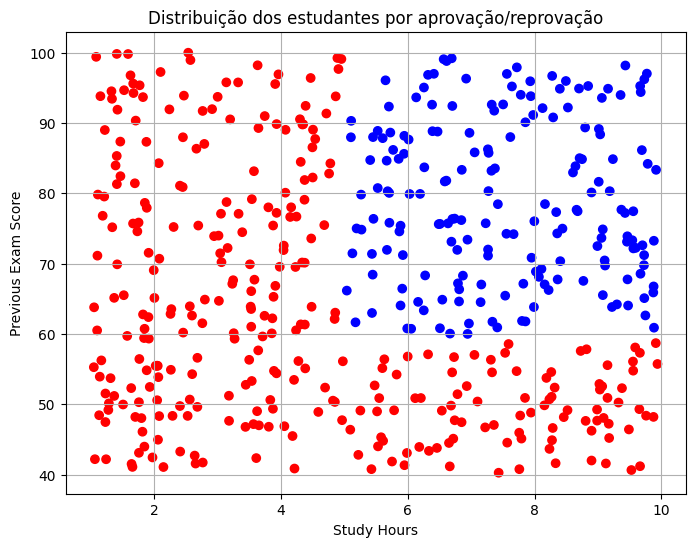

In [47]:
colors = np.array(['red', 'blue'])

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=colors[y])
plt.xlabel('Study Hours')
plt.ylabel('Previous Exam Score')
plt.title('Distribuição dos estudantes por aprovação/reprovação')
plt.grid(True)
plt.show()

O gráfico mostra a distribuição dos estudantes de acordo com as horas de estudo e a nota do exame anterior.
As cores representam as classes Pass/Fail (Aprovado/Reprovado).

###Normalização dos dados

In [48]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

### Prepara os dados para o PyTorch

In [49]:
# Variáveis usadas pelo plotter e pelo treinamento
Xc = X_scaled
Y = y

# Conversão para tensores PyTorch
X_tensor = torch.FloatTensor(X_scaled)
Y_tensor = torch.LongTensor(y)

print("Shape de X_tensor:", X_tensor.shape)
print("Shape de Y_tensor:", Y_tensor.shape)

Shape de X_tensor: torch.Size([500, 2])
Shape de Y_tensor: torch.Size([500])


## Construindo o modelo da rede

In [50]:
model = nn.Linear(2, 2)  # 2 entradas e 2 saídas

In [51]:
model.state_dict()

OrderedDict([('weight',
              tensor([[ 0.4678, -0.4525],
                      [ 0.6708,  0.5171]])),
             ('bias', tensor([0.5229, 0.5379]))])

### Fazendo um predict

In [52]:
out = model(X_tensor[:4, :])  # 4 amostras
out

tensor([[-0.0145,  0.6512],
        [ 1.1459,  1.6526],
        [ 1.1624,  0.7501],
        [ 0.1534,  1.3647]], grad_fn=<AddmmBackward0>)

In [53]:
oo = F.softmax(out,dim=1)
oo

tensor([[0.3395, 0.6605],
        [0.3760, 0.6240],
        [0.6017, 0.3983],
        [0.2295, 0.7705]], grad_fn=<SoftmaxBackward0>)

### Calculando as probabilidades com Softmax

- [Wikipedia:Softmax_function](https://en.wikipedia.org/wiki/Softmax_function)

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/softmax.png)

In [54]:
F.softmax(out,dim=1)*100

tensor([[33.9469, 66.0531],
        [37.5976, 62.4024],
        [60.1662, 39.8338],
        [22.9481, 77.0519]], grad_fn=<MulBackward0>)

### Predição da classe

In [55]:
prob,y_pred = torch.max(F.softmax(out,dim=1),dim=1)
print(y_pred)
print(prob)

tensor([1, 1, 0, 1])
tensor([0.6605, 0.6240, 0.6017, 0.7705], grad_fn=<MaxBackward0>)


## Treinamento

### Classe para visualização dinâmica

In [56]:
from IPython.display import clear_output

class MyPlotter:
    def __init__(self, model, X, Y, n_epoch):
        self.model = model
        self.X = X
        self.Y = Y
        self.n_epoch = n_epoch
        self.losses = []

    def on_epoch_end(self, epoch, logs):
        self.losses.append(logs['loss'])

        # Atualiza o gráfico a cada 500 épocas para não deixar o Colab pesado
        if epoch % 500 != 0 and epoch != self.n_epoch - 1:
            return

        clear_output(wait=True)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Gráfico da perda
        axes[0].plot(self.losses)
        axes[0].set_title('Evolução da perda')
        axes[0].set_xlabel('Época')
        axes[0].set_ylabel('Loss')
        axes[0].grid(True)

        # Fronteira de decisão
        x_min, x_max = self.X[:, 0].min() - 0.5, self.X[:, 0].max() + 0.5
        y_min, y_max = self.X[:, 1].min() - 0.5, self.X[:, 1].max() + 0.5

        xx, yy = np.meshgrid(
            np.linspace(x_min, x_max, 200),
            np.linspace(y_min, y_max, 200)
        )

        grid = np.c_[xx.ravel(), yy.ravel()]
        grid_tensor = torch.FloatTensor(grid)

        with torch.no_grad():
            outputs = self.model(grid_tensor)
            _, preds = torch.max(outputs, dim=1)

        Z = preds.numpy().reshape(xx.shape)

        colors = np.array(['red', 'blue'])

        axes[1].contourf(xx, yy, Z, alpha=0.25)
        axes[1].scatter(self.X[:, 0], self.X[:, 1], c=colors[self.Y], edgecolor='k')
        axes[1].set_title(f'Fronteira de decisão - Época {epoch + 1}')
        axes[1].set_xlabel('Study Hours normalizado')
        axes[1].set_ylabel('Previous Exam Score normalizado')
        axes[1].grid(True)

        plt.show()

### Laço principal de treinamento da Regressão Logística por Softmax

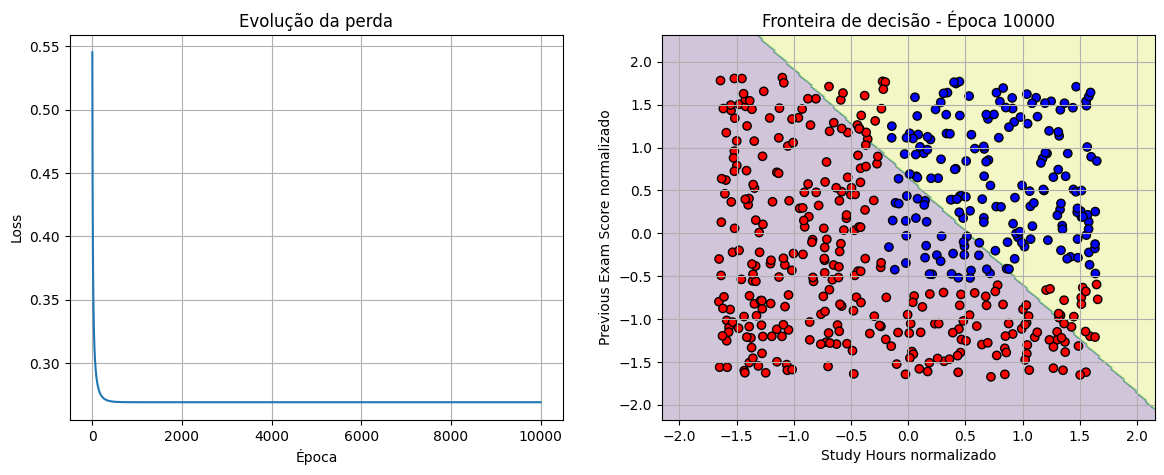

Final loss: 0.2691341042518616


In [57]:
lr = 0.15

optimizer = torch.optim.SGD(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

nb_epoch = 10000

# Definindo o plotter
my_plot = MyPlotter(model, Xc, Y, nb_epoch)

losses = []

for i in range(nb_epoch):

    # Predict da rede
    output = model(X_tensor)

    # Calcula a perda
    loss = criterion(output, Y_tensor)

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    my_plot.on_epoch_end(i, {'loss': loss.item()})
    final_loss = loss.item()

print('Final loss:', final_loss)

## Avaliação

### Parâmetros após treinamento

In [58]:
model.state_dict()

OrderedDict([('weight',
              tensor([[-0.9691, -1.1922],
                      [ 2.1077,  1.2569]])),
             ('bias', tensor([ 1.3348, -0.2740]))])

### Salvando os parâmetros treinados

In [59]:
import os

os.makedirs('../models', exist_ok=True)

torch.save(model.state_dict(), '../models/RegrLog_StudentExam.pt')

In [60]:
! ls ../models/

RegrLog_StudentExam.pt


In [61]:
nn.init.constant_(model.weight, 0)
nn.init.constant_(model.bias, 0)

model.state_dict()

OrderedDict([('weight',
              tensor([[0., 0.],
                      [0., 0.]])),
             ('bias', tensor([0., 0.]))])

### Recuperando os pesos salvos

In [62]:
param_saved = torch.load('../models/RegrLog_StudentExam.pt')

model.load_state_dict(param_saved)

model.state_dict()

OrderedDict([('weight',
              tensor([[-0.9691, -1.1922],
                      [ 2.1077,  1.2569]])),
             ('bias', tensor([ 1.3348, -0.2740]))])

In [63]:
def predict(model, input_data):
    model.eval()

    with torch.no_grad():
        outputs = model(input_data)
        _, predicts = torch.max(outputs, 1)

    return predicts.numpy()

### Exatidão (acurácia) do classificador

Acurácia indica o número de acertos sobre o número total de amostras

In [64]:
Y_pred = predict(model, X_tensor)

accuracy = (Y_pred == Y).mean()

print('Training Accuracy:', accuracy)

Training Accuracy: 0.868


### Matriz de confusão

In [65]:
matriz_confusao = pd.crosstab(
    pd.Series(Y_pred, name='Predito'),
    pd.Series(Y, name='Real'))

matriz_confusao

Real,0,1
Predito,,
0,284,34
1,32,150


In [67]:
acertos = np.trace(matriz_confusao.values)
total = matriz_confusao.values.sum()

acuracia_matriz = acertos / total

print("Acurácia calculada pela matriz de confusão:", acuracia_matriz)

Acurácia calculada pela matriz de confusão: 0.868


## Atividades

### Perguntas:

**1. Observe que se após o treinamento, a célula for executada novamente, ela continua utilizando os parâmetros treinados até sua última execução. O que é preciso fazer para que o treinamento comece deste o início, como da primeira vez que foi executado?**
Para que o treinamento comece do zero, é necessário recriar o modelo e o otimizador:

model = nn.Linear(2, 2)
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

Isso reinicializa os pesos e impede que o modelo continue treinando a partir dos parâmetros já ajustados.

**2. Experimente refazer o treinamento com diferentes valores de learning rate**

Ao refazer o treinamento com diferentes valores de learning rate, é possível observar que:
- valores muito baixos tornam o treinamento mais lento;
- valores adequados reduzem a perda de forma estável;
- valores muito altos podem fazer a perda oscilar ou dificultar a convergência.

Neste notebook, foi utilizado lr = 0.15, que conseguiu reduzir a perda e gerar uma acurácia de aproximadamente 0.868.

### Exercícios:

1. Observando o gráfico de máxima probabilidade, responda:
    1. Qual é a amostra classificada corretamente, com maior probabilidade?
    
    2. Qual é a amostra classificada erradamente, com maior probabilidade?
    
    3. Qual é a amostra classificada corretamente, com menor probabilidade?
    4. Qual é a amostra classificada erradamente, com menor probabilidade?

**2. Quantos parâmetros possui esta rede? Quantos são da camada densa e quantos são de bias?**
A rede possui uma camada Linear(2, 2).
Pesos da camada densa: 2 entradas x 2 saídas = 4 pesos.
Bias: 2 valores, um para cada saída.
Total: 4 + 2 = 6 parâmetros.

**3. Quantas entradas e quantas saídas esta rede possui?**
A rede possui 2 entradas:
- Study Hours
- Previous Exam Score

A rede possui 2 saídas:
- classe 0: Fail
- classe 1: Pass

**4. Como se pode calcular a acurácia a partir da matriz de confusão?**
A acurácia é calculada somando os valores da diagonal principal, que representam os acertos, e dividindo pelo total de amostras.

Pela matriz obtida:
acertos = 284 + 150 = 434
total = 500
acurácia = 434 / 500 = 0.868

**5. O que faz a função `torch.max`? Quantos parâmetros ela retorna e quais seus significados?**
    - http://pytorch.org/docs/master/torch.html?highlight=torch%20max#torch.max

A função torch.max retorna o maior valor de um tensor.
Quando usamos torch.max(tensor, dim=1), ela retorna dois valores:
- o maior valor de cada linha;
- o índice onde esse maior valor aparece.

Neste problema de classificação, o maior valor representa a maior probabilidade e o índice representa a classe prevista pelo modelo.


In [76]:
#1 Exercício
model.eval()

with torch.no_grad():
    outputs = model(X_tensor)
    probs = F.softmax(outputs, dim=1)
    prob_max, pred_classes = torch.max(probs, dim=1)

pred_np = pred_classes.numpy()
prob_np = prob_max.numpy()

resultado_prob = pd.DataFrame({
    'Study Hours': X[:, 0],
    'Previous Exam Score': X[:, 1],
    'Real': Y,
    'Predito': pred_np,
    'Probabilidade': prob_np,
    'Correto': pred_np == Y
})

resultado_prob.head()

,Study Hours,Previous Exam Score,Real,Predito,Probabilidade,Correto
0,4.370861,81.889703,0,0,0.737116,True
1,9.556429,72.165782,1,1,0.971209,True
2,7.587945,58.571657,0,0,0.664263,True
3,6.387926,88.827701,1,1,0.906605,True
4,2.404168,81.083870,0,0,0.967692,True


In [72]:
#1.1 Exercício
correta_maior_prob = resultado_prob[resultado_prob['Correto'] == True].sort_values(
    by='Probabilidade',
    ascending=False
).head(1)

correta_maior_prob

,Study Hours,Previous Exam Score,Real,Predito,Probabilidade,Correto
128,1.062569,42.200992,0,0,0.999972,True


In [73]:
#1.2 Exercício
errada_maior_prob = resultado_prob[resultado_prob['Correto'] == False].sort_values(
    by='Probabilidade',
    ascending=False
).head(1)

errada_maior_prob

,Study Hours,Previous Exam Score,Real,Predito,Probabilidade,Correto
494,5.173286,61.658434,1,0,0.952893,False


In [74]:
#1.3 Exercício
correta_menor_prob = resultado_prob[resultado_prob['Correto'] == True].sort_values(
    by='Probabilidade',
    ascending=True
).head(1)

correta_menor_prob

,Study Hours,Previous Exam Score,Real,Predito,Probabilidade,Correto
227,4.53788,87.716039,0,0,0.50146,True


In [75]:
#1.4 Exercício
errada_menor_prob = resultado_prob[resultado_prob['Correto'] == False].sort_values(
    by='Probabilidade',
    ascending=True
).head(1)

errada_menor_prob

,Study Hours,Previous Exam Score,Real,Predito,Probabilidade,Correto
367,9.148156,50.915688,0,1,0.502379,False


**1.1 Amostra classificada corretamente com maior probabilidade:** índice 128, probabilidade 0.999972, classe real 0 e classe predita 0.

**1.2 Amostra classificada erradamente com maior probabilidade:** índice 494, probabilidade 0.952893, classe real 1 e classe predita 0.

**1.3 Amostra classificada corretamente com menor probabilidade:** índice 227, probabilidade 0.501460, classe real 0 e classe predita 0.

**1.4 Amostra classificada erradamente com menor probabilidade:** índice 367, probabilidade 0.502379, classe real 0 e classe predita 1.

## Principais aprendizados

Nesta atividade, foi feita a adaptação do notebook de Regressão Logística com Iris para o dataset Student Exam Performance Prediction.

O objetivo foi prever se um estudante seria aprovado ou reprovado usando duas variáveis de entrada: Study Hours e Previous Exam Score.

A rede utilizada possui 2 entradas e 2 saídas, uma para cada classe possível: Fail e Pass.

O modelo foi treinado com CrossEntropyLoss e otimizador SGD.
A função softmax foi utilizada para transformar os scores da rede em probabilidades.

A acurácia obtida foi de aproximadamente 0.868, indicando que o modelo classificou corretamente cerca de 86,8% das amostras.

A matriz de confusão mostrou 284 acertos para a classe 0 e 150 acertos para a classe 1.
Também houve 34 erros em que estudantes aprovados foram classificados como reprovados e 32 erros em que estudantes reprovados foram classificados como aprovados.

A fronteira de decisão mostrou visualmente como o modelo separou as classes no espaço das variáveis normalizadas.